In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv
from pathlib import Path

In [23]:
load_dotenv()
SERVER = os.environ.get("DB_SERVER")
DATABASE = os.environ.get("DB_NAME")
DRIVER = os.environ.get("DB_DRIVER")
PATH_STRING = os.environ.get("FILE_PATH")

QUERIES_FOLDER = Path(PATH_STRING) / "queries" 
SQL_FILE_PATH = QUERIES_FOLDER / "cohort.sql"


In [24]:
# extract the query into df

with open(SQL_FILE_PATH, 'r') as file: 
    sql_query = file.read()

engine = create_engine(f"mssql+pyodbc://{SERVER}/{DATABASE}?driver={DRIVER}&trusted_connection=yes")

df = pd.read_sql_query(sql_query, con=engine)


ResourceClosedError: This result object does not return rows. It has been closed automatically.

<function matplotlib.pyplot.show(close=None, block=None)>

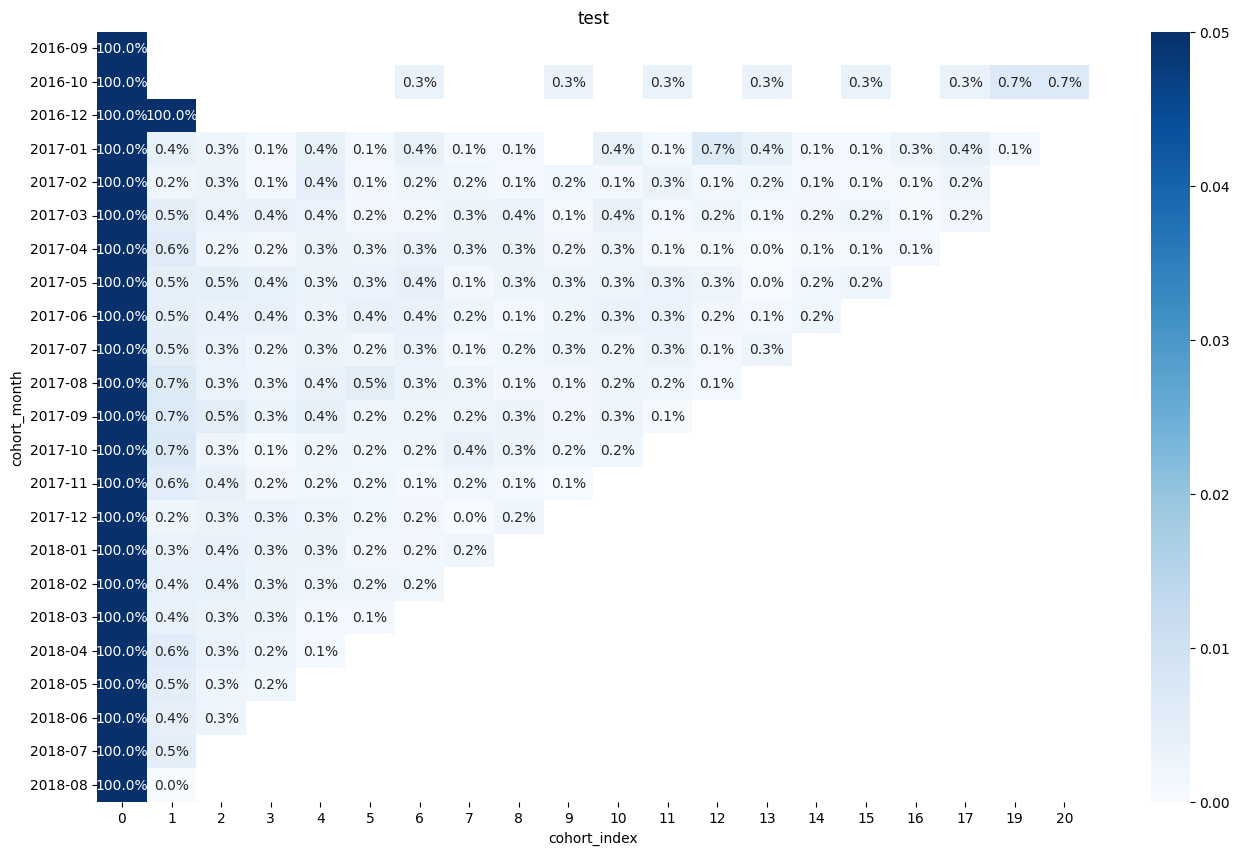

In [ ]:
# convert dates to date time
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['birth_date'] = pd.to_datetime(df['birth_date'])

# get the months
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['cohort_month'] = df['birth_date'].dt.to_period('M')

df['cohort_index'] = (df['purchase_month'] - df['cohort_month']).apply(lambda x: x.n if pd.notnull(x) else 0)

cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()

retention_matrix = cohort_data.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')

cohort_sizes= retention_matrix.iloc[:,0]
retention_precentage = retention_matrix.divide(cohort_sizes, axis=0)


plt.figure(figsize=(16,10))
sns.heatmap(retention_precentage, annot=True, fmt='.1%', cmap='Blues', vmin=0.0, vmax=0.05)
plt.title('test')
plt.show

